# **Dataset API Prototype**

In [1]:
import numpy as np
import tensorflow as tf
import os
import matplotlib.pyplot as plt


2026-06-04 02:41:32.207131: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## WM_811K Dataset Class

In [2]:
from datasets import WM_811K
wm811k = WM_811K(imsize=(96,96))

reading wafermaps


  0%|          | 0/12822 [00:00<?, ?it/s]

## Single Defect Tensorflow Dataset

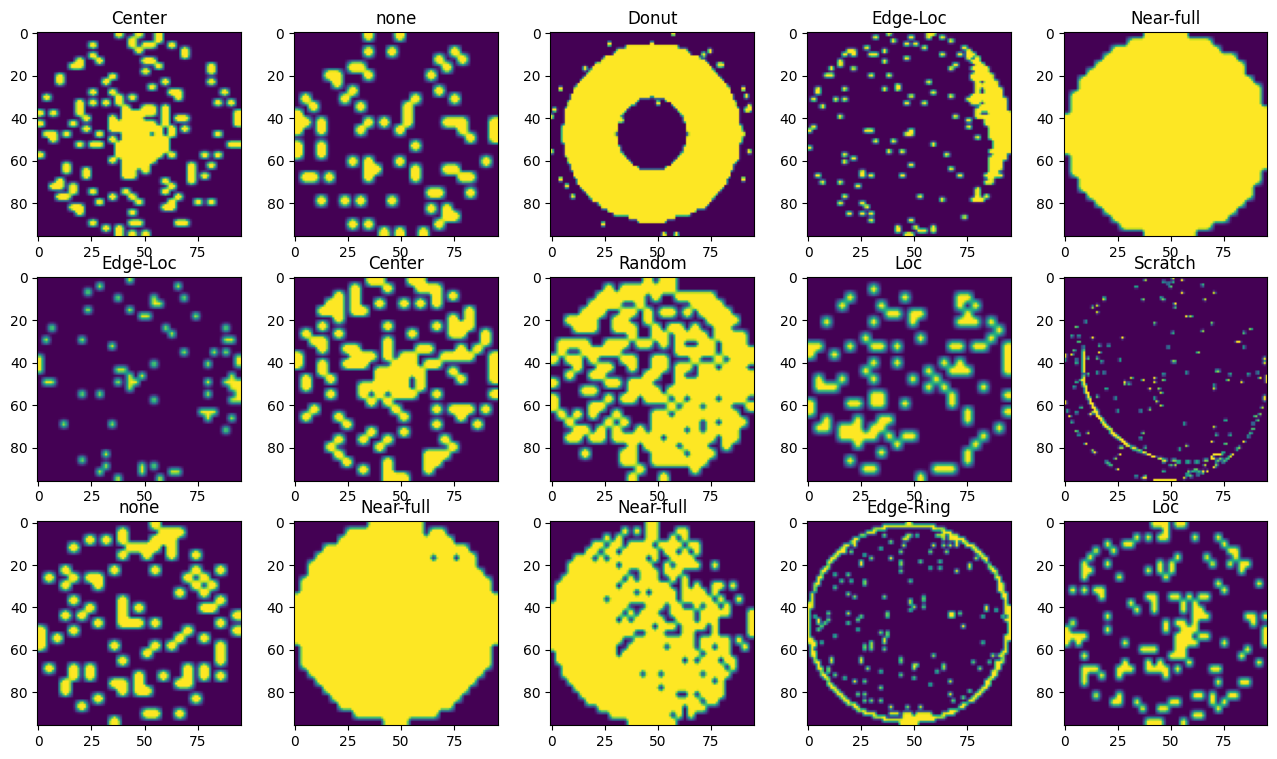

In [3]:
N_VIEW = 15
cols = min(N_VIEW, 5)
rows = (N_VIEW + cols - 1) // cols

_,axs = plt.subplots(rows,cols, figsize=(16,9))

ds = wm811k.dataset_single_defect()
for ax, (img, label) in zip(axs.flatten(), ds.take(N_VIEW)):
    ax.imshow(img)
    i = np.argmax(label) if np.sum(label) != 0.0 else -1
    ax.set_title(WM_811K.defect_from_int[i])
    

none


2026-06-04 02:41:56.885086: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


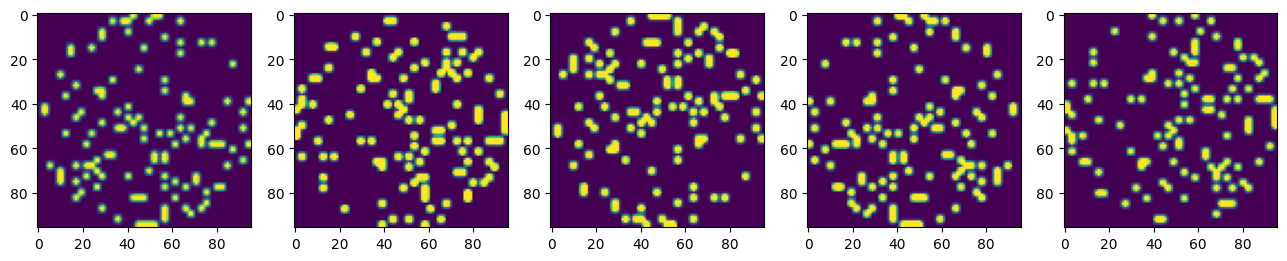

In [4]:
for img, label in ds.take(1):
    _, axs = plt.subplots(1,5, figsize=(16,4))
    axs[0].imshow(img)
    axs[1].imshow(wm811k.augment_image(img))
    axs[2].imshow(wm811k.augment_image(img))
    axs[3].imshow(wm811k.augment_image(img))
    axs[4].imshow(wm811k.augment_image(img))
    i = np.argmax(label) if np.sum(label) != 0.0 else -1
    print(WM_811K.defect_from_int[i])

## Multi Defect Tensorflow Dataset

2026-06-04 02:41:59.218225: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


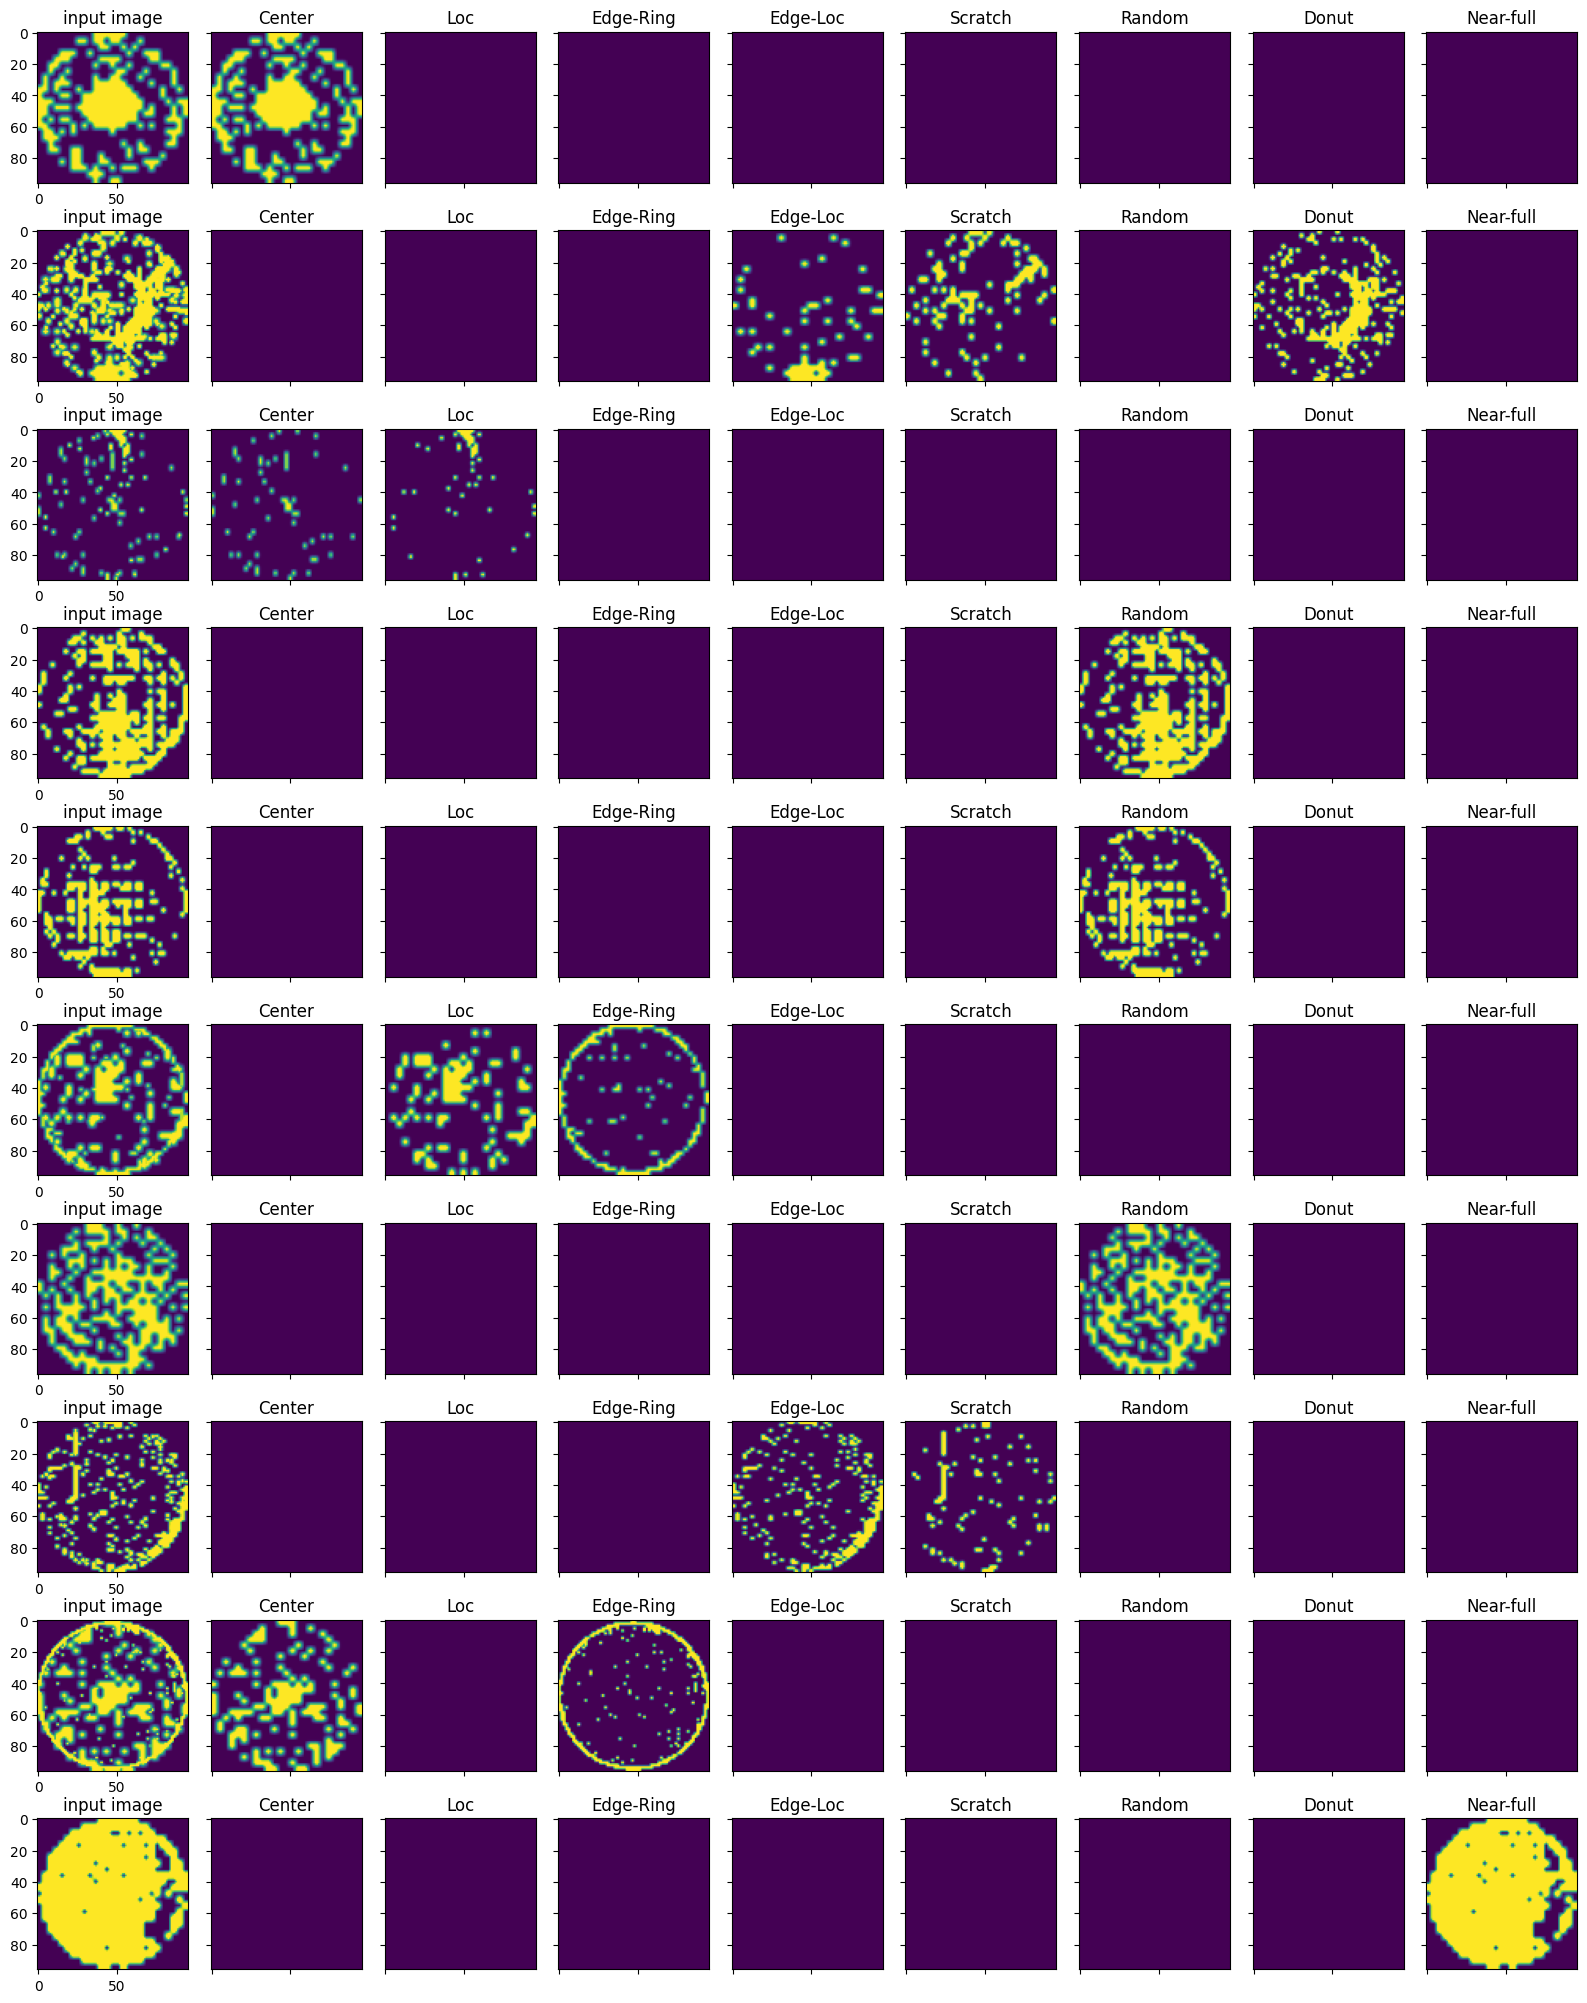

In [5]:
N_VIEW = 10
_,axs = plt.subplots(N_VIEW, 9, figsize=(16, 2*N_VIEW))

ds = wm811k.dataset_multi_defect_segmentation()
for row, (input_img, mid_stack) in enumerate(ds.take(N_VIEW)):
    axs[row,0].imshow(input_img)
    axs[row,0].set_title('input image')
    for col in range(8):
        axs[row,col+1].imshow(mid_stack[:,:,col])
        axs[row,col+1].set_title(WM_811K.defect_from_int[col])
        axs[row,col+1].set_xticklabels([])
        axs[row,col+1].set_yticklabels([])

plt.tight_layout()

## 1. Train Segmentation Model

In [6]:
# create segmentation model with U-Net like structure
def create_segmentation_model():
    def conv_block(x, f, pad='valid', halve=True):
        if halve:
            x = tf.keras.layers.MaxPooling2D((2,2))(x)
        x = tf.keras.layers.Conv2D(f, (3,3), activation='relu', padding=pad)(x)
        x = tf.keras.layers.Conv2D(f, (3,3), activation='relu', padding=pad)(x)
        x = tf.keras.layers.Dropout(0.25)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        return x

    def deconv_block(xA, xB, f, pad='valid', double=True):
        x = tf.keras.layers.Concatenate(axis=-1)([xA,xB])
        x = tf.keras.layers.Conv2DTranspose(f, (3,3), activation='relu', padding=pad)(x)
        x = tf.keras.layers.Conv2DTranspose(f, (3,3), activation='relu', padding=pad)(x)
        x = tf.keras.layers.Dropout(0.25)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        if double:
            x = tf.keras.layers.Conv2DTranspose(f//2, (2,2), activation='relu', strides=(2,2))(x)
        return x

    img_input = tf.keras.layers.Input(shape=(*wm811k.imsize, 1))

    # encoder blocks
    x1 = conv_block(img_input, 32, 'same', False)
    x2 = conv_block(x1, 64)
    x3 = conv_block(x2, 128)
    x4 = conv_block(x3, 256)

    # dense block
    x5 = tf.keras.layers.GlobalAveragePooling2D()(x4)
    x5 = tf.keras.layers.Dense(256)(x5)
    x5 = tf.keras.layers.Dropout(0.5)(x5)
    x5 = tf.keras.layers.Reshape((1,1,256))(x5)
    x5 = tf.keras.layers.Conv2DTranspose(64, (5,5), activation='relu')(x5)

    # decoder blocks
    x6 = deconv_block(x4, x5, 128)
    x7 = deconv_block(x3, x6, 128)
    x8 = deconv_block(x2, x7, 64)
    x9 = deconv_block(x1, x8, 32, 'same', False)

    imgs_output = tf.keras.layers.Conv2D(WM_811K.n_classes-1, (3,3), activation='sigmoid', padding='same')(x9)
    return tf.keras.Model(inputs=img_input, outputs=imgs_output)


model_segmentation = create_segmentation_model()
model_segmentation.compile(
    loss=tf.keras.losses.MSE,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
)
model_segmentation.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 96, 96,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 96, 96,    │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 96, 96,    │          0 │ conv2d_1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 96, 96,    │        128 │ dropout[0][0]     │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 46, 46,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 44, 44,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 44, 44,    │          0 │ conv2d_3[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 44, 44,    │        256 │ dropout_1[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 22, 22,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 20, 20,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 18, 18,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 18, 18,    │          0 │ conv2d_5[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 18, 18,    │        512 │ dropout_2[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 9, 9, 128) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 7, 7, 256) │    295,168 │ max_pooling2d_2[

 Total params: 2,750,344 (10.49 MB)

 Trainable params: 2,748,680 (10.49 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [7]:
model_segmentation = tf.keras.models.load_model(os.path.join('..', 'models', 'multi_defect_segmentation.keras'))

In [8]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join('..', 'models', 'multi_defect_segmentation_david.keras'),
        monitor='loss',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )
]

ds_train = wm811k.dataset_multi_defect_segmentation().batch(16)

history = model_segmentation.fit(
    x=ds_train,
    steps_per_epoch=64,
    epochs=40,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 811ms/step - loss: 0.0263
Epoch 1: loss improved from None to 0.02604, saving model to ../models/multi_defect_segmentation_david.keras

Epoch 1: finished saving model to ../models/multi_defect_segmentation_david.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 57s 816ms/step - loss: 0.0260
Epoch 2/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 836ms/step - loss: 0.0259
Epoch 2: loss improved from 0.02604 to 0.02562, saving model to ../models/multi_defect_segmentation_david.keras

Epoch 2: finished saving model to ../models/multi_defect_segmentation_david.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 842ms/step - loss: 0.0256
Epoch 3/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 971ms/step - loss: 0.0245
Epoch 3: loss did not improve from 0.02562
64/64 ━━━━━━━━━━━━━━━━━━━━ 62s 971ms/step - loss: 0.0258
Epoch 4/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 918ms/step - loss: 0.0246
Epoch 4: loss improved from 0.02562 to 0.02479, saving model to ../models/multi_defect_segmentation_david.keras

Epoch 4: finished 

In [9]:
input_img_batch, output_imgs_batch = list(ds_train.take(1))[0]
pred_batch = model_segmentation.predict(input_img_batch)

2026-06-04 03:22:00.436591: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 796ms/step


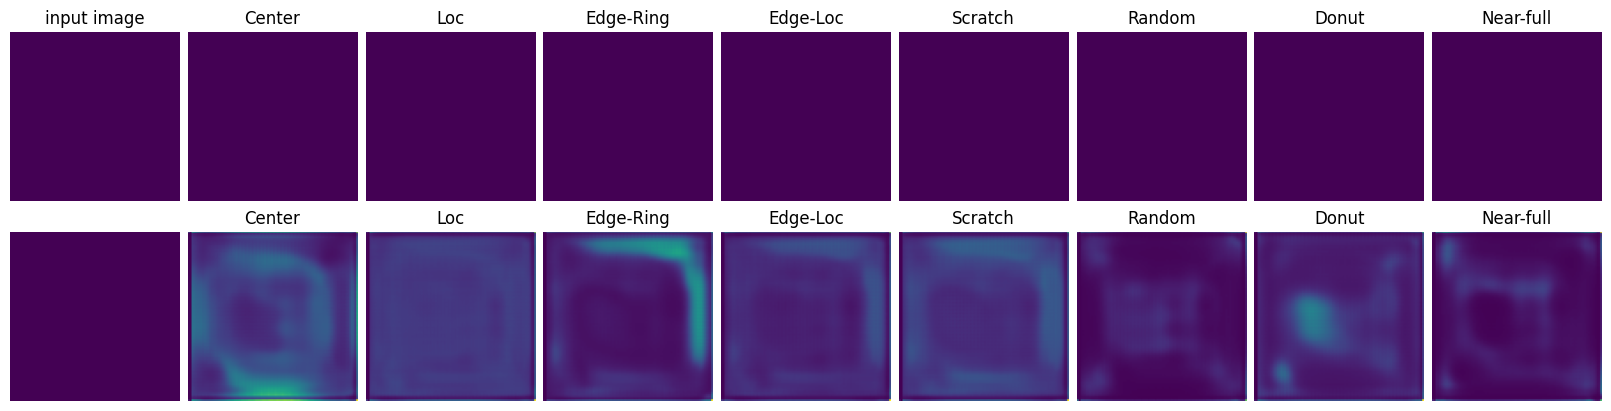

In [10]:
idx = 3
_,axs = plt.subplots(2,9, figsize=(16,4), layout='constrained')

axs[0,0].set_title('input image')
axs[0,0].imshow(input_img_batch[idx,:,:,0])
axs[1,0].imshow(np.zeros(wm811k.imsize))
for c in range(8):
    axs[0,c+1].set_title(WM_811K.defect_from_int[c])
    axs[0,c+1].imshow(output_imgs_batch[idx,:,:,c])
    axs[1,c+1].set_title(WM_811K.defect_from_int[c])
    axs[1,c+1].imshow(pred_batch[idx,:,:,c])

for ax in axs.flatten():
    ax.set_axis_off()

plt.savefig(os.path.join('..', 'plots', 'segmentation_sample.png'))

## 2. Train Classification Model with spatial attention

In [11]:
class SpatialAttention(tf.keras.layers.Layer):
    def __init__(self, kernel_size=7, **kwargs):
        """
        kernel_size: 7x7 is the standard established by the CBAM paper. 
        It gives the convolution a wide enough receptive field to understand 
        the geometry around a pixel.
        """
        super(SpatialAttention, self).__init__(**kwargs)
        
        # The single convolution layer that creates the final mask
        self.conv = tf.keras.layers.Conv2D(
            filters=1, 
            kernel_size=kernel_size, 
            padding='same', 
            activation='sigmoid', 
            use_bias=False # Bias is unnecessary here
        )

    def call(self, inputs):
        # 1. Average Pooling across the channel axis (axis=-1)
        # Shape changes from (B, H, W, C) -> (B, H, W, 1)
        avg_pool = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        
        # 2. Max Pooling across the channel axis
        # Shape changes from (B, H, W, C) -> (B, H, W, 1)
        max_pool = tf.reduce_max(inputs, axis=-1, keepdims=True)
        
        # 3. Concatenate the two maps together
        # Shape becomes (B, H, W, 2)
        concat = tf.concat([avg_pool, max_pool], axis=-1)
        
        # 4. Pass through convolution and sigmoid to generate the mask
        # Shape becomes (B, H, W, 1), with values between 0.0 and 1.0
        attention_mask = self.conv(concat)
        
        # 5. Multiply the mask against the original inputs
        return inputs * attention_mask

    # Required so you can save and load your model later without errors
    def get_config(self):
        config = super(SpatialAttention, self).get_config()
        return config

model_classification = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(*wm811k.imsize,WM_811K.n_classes-1)),
                          
    # ---- Conv block 1 -------------------------------------------------
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    SpatialAttention(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # ---- Conv block 2 -------------------------------------------------
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    SpatialAttention(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # ---- Conv block 3 -------------------------------------------------
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    SpatialAttention(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # ---- Flatten + Dense -----------------------------------------------
    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(WM_811K.n_classes-1, activation='sigmoid'),
#    tf.keras.layers.Dense(WM_811K.n_classes-1, activation='softmax')
    
    ])

#model_classification.compile(
#    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
#    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),
#)

model_classification.compile(
     optimizer='adam',
     loss='binary_crossentropy',
     metrics=[tf.keras.metrics.AUC(multi_label=True, name='auc')]
)

model_classification.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 94, 94, 32)     │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_attention               │ (None, 94, 94, 32)     │            98 │
│ (SpatialAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 47, 47, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_attention_1             │ (None, 45, 45, 64)     │            98 │
│ (SpatialAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 22, 22, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_attention_2             │ (None, 20, 20, 128)    │            98 │
│ (SpatialAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 10, 10, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │     6,554,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │             

 Total params: 6,920,846 (26.40 MB)

 Trainable params: 6,918,350 (26.39 MB)

 Non-trainable params: 2,496 (9.75 KB)

## 3. Train Combined Full Stack Model

In [12]:
ds_train = wm811k.dataset_multi_defect_fullstack().batch(16)
ds_validation = wm811k.dataset_multi_defect_fullstack().batch(16)

In [13]:
# stage 1: Train Classification Only

#freeze  segmentation model
model_segmentation.trainable = False


model_fullstack = tf.keras.models.Sequential([
    model_segmentation,
    model_classification 
])

model_fullstack.summary()

#model_fullstack.compile(
#    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
#    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
#    metrics=["accuracy"]
#)

model_fullstack.compile(
     optimizer='adam',
     loss='binary_crossentropy',
     metrics=[tf.keras.metrics.AUC(multi_label=True, name='auc')]
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join('..', 'models', 'multi_defect_fullstack_attention_unet.keras'),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=50,
        restore_best_weights=True,
        verbose=1
    )
]


# Train Stage 1
print("Starting Stage 1: Training Classification Head Only...")
history_stage1 = model_fullstack.fit(
    x=ds_train,
    steps_per_epoch=128,
    validation_data=ds_validation,
    validation_steps=32,
    epochs=20, # Train just enough for the classification head to converge
    #callbacks=callbacks,
    verbose=1
)



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional_41 (Functional)      │ (None, 96, 96, 8)      │     2,750,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 8)              │     6,920,846 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,671,190 (36.89 MB)

 Trainable params: 6,918,350 (26.39 MB)

 Non-trainable params: 2,752,840 (10.50 MB)

Starting Stage 1: Training Classification Head Only...
Epoch 1/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 111s 806ms/step - auc: 0.8115 - loss: 0.5735 - val_auc: 0.8753 - val_loss: 0.5192
Epoch 2/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 104s 811ms/step - auc: 0.8508 - loss: 0.3847 - val_auc: 0.8597 - val_loss: 0.5338
Epoch 3/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 101s 787ms/step - auc: 0.8746 - loss: 0.3223 - val_auc: 0.8653 - val_loss: 0.5982
Epoch 4/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 103s 807ms/step - auc: 0.8861 - loss: 0.2982 - val_auc: 0.8950 - val_loss: 0.4458
Epoch 5/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 105s 821ms/step - auc: 0.8895 - loss: 0.2965 - val_auc: 0.9049 - val_loss: 0.3767
Epoch 6/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 97s 756ms/step - auc: 0.8995 - loss: 0.2775 - val_auc: 0.9165 - val_loss: 0.2872
Epoch 7/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 99s 771ms/step - auc: 0.9083 - loss: 0.2570 - val_auc: 0.9145 - val_loss: 0.2905
Epoch 8/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 99s 773ms/step - auc: 0.9099 - loss: 0.2649 - val_auc

In [14]:

# stage 2 Train the Entire Model

#  Unfreeze  segmentation model
model_segmentation.trainable = True

#model_fullstack.compile(
#    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
#    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), # Reduced learning rate
#    metrics=["accuracy"]
#)
model_fullstack.compile(
     optimizer='adam',
     loss='binary_crossentropy',
     metrics=[tf.keras.metrics.AUC(multi_label=True, name='auc')]
)


callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join('..', 'models', 'multi_defect_fullstack_attention_unet.keras'),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1
    )
]


#  Train Stage 2
print("Starting Stage 2: Fine-tuning Full Model...")
history_stage2 = model_fullstack.fit(
    x=ds_train,
    steps_per_epoch=128,
    validation_data=ds_validation,
    validation_steps=32,
    epochs=50, 
    callbacks=callbacks,
    verbose=1
)

Starting Stage 2: Fine-tuning Full Model...
Epoch 1/50


128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - auc: 0.8998 - loss: 0.2874
Epoch 1: val_loss improved from None to 0.30742, saving model to ../models/multi_defect_fullstack_attention_unet.keras

Epoch 1: finished saving model to ../models/multi_defect_fullstack_attention_unet.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - auc: 0.9121 - loss: 0.2657 - val_auc: 0.9209 - val_loss: 0.3074
Epoch 2/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - auc: 0.9160 - loss: 0.2593
Epoch 2: val_loss improved from 0.30742 to 0.21091, saving model to ../models/multi_defect_fullstack_attention_unet.keras

Epoch 2: finished saving model to ../models/multi_defect_fullstack_attention_unet.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - auc: 0.9133 - loss: 0.2619 - val_auc: 0.9422 - val_loss: 0.2109
Epoch 3/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - auc: 0.9185 - loss: 0.2512
Epoch 3: val_loss improved from 0.21091 to 0.21039, saving model to ../models/multi_defect_fullstack_attention_unet.keras

Epoch 3: fini

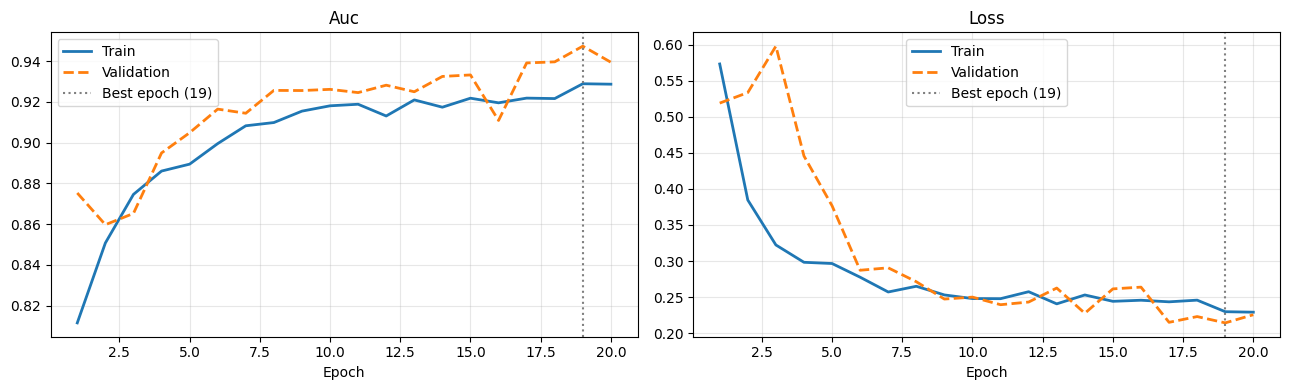

Saved ./performance_plots/training_curves_attention_unet_stage1.png


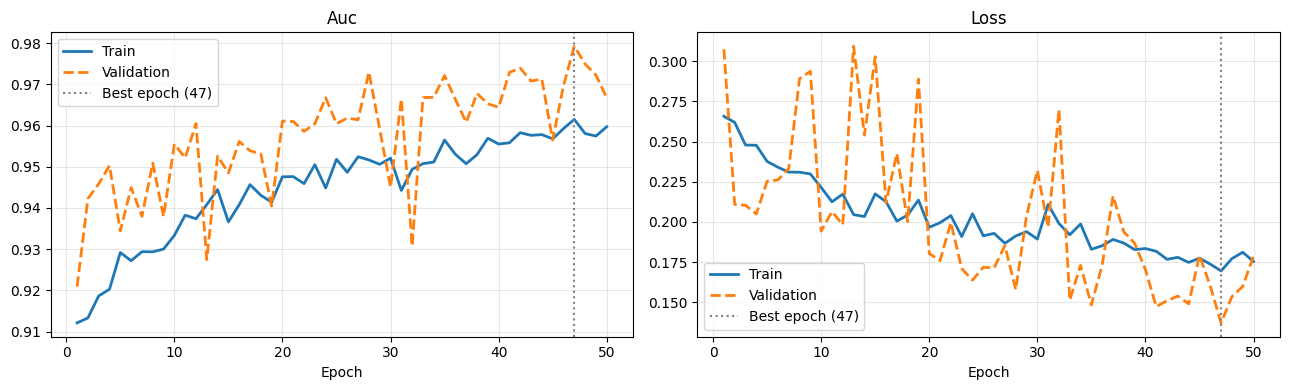

Saved ./performance_plots/training_curves_attention_unet_stage2.png


In [15]:
def plot_training_curves(history_dict, out_path):
    epochs  = range(1, len(history_dict["loss"]) + 1)
    best_ep = history_dict["best_epoch"]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    for ax, metric in [(ax1, "auc"), (ax2, "loss")]:
        ax.plot(epochs, history_dict[metric],          label="Train",      linewidth=2)
        ax.plot(epochs, history_dict[f"val_{metric}"], label="Validation", linewidth=2, linestyle="--")
        ax.axvline(best_ep, color="gray", linestyle=":", label=f"Best epoch ({best_ep})")
        ax.set_title(metric.capitalize()); ax.set_xlabel("Epoch"); ax.grid(True, alpha=0.3); ax.legend()
    plt.tight_layout(); plt.savefig(out_path, dpi=150); plt.show()
    print(f"Saved {out_path}")

history_dict = dict(history_stage1.history)
history_dict = {k: [float(v) for v in vals] for k, vals in history_stage1.history.items()}
history_dict["best_epoch"]        = int(np.argmin(history_stage1.history["val_loss"])) + 1
history_dict["best_val_accuracy"] = float(min(history_stage1.history["val_loss"]))

OUTPUT_DIR   = "./performance_plots"   # all performance plots written here

plot_training_curves(history_dict, out_path=os.path.join(OUTPUT_DIR, "training_curves_attention_unet_stage1.png"))

history_dict2 = dict(history_stage2.history)
history_dict2 = {k: [float(v) for v in vals] for k, vals in history_stage2.history.items()}
history_dict2["best_epoch"]        = int(np.argmin(history_stage2.history["val_loss"])) + 1
history_dict2["best_val_accuracy"] = float(min(history_stage2.history["val_loss"]))

OUTPUT_DIR   = "./performance_plots"   # all performance plots written here

plot_training_curves(history_dict2, out_path=os.path.join(OUTPUT_DIR, "training_curves_attention_unet_stage2.png"))

In [50]:
input_img_batch, output_imgs_batch = list(wm811k.dataset_multi_defect_segmentation().batch(32).take(1))[0]
pred_batch = model_segmentation.predict(input_img_batch)

2026-06-04 13:42:10.983008: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


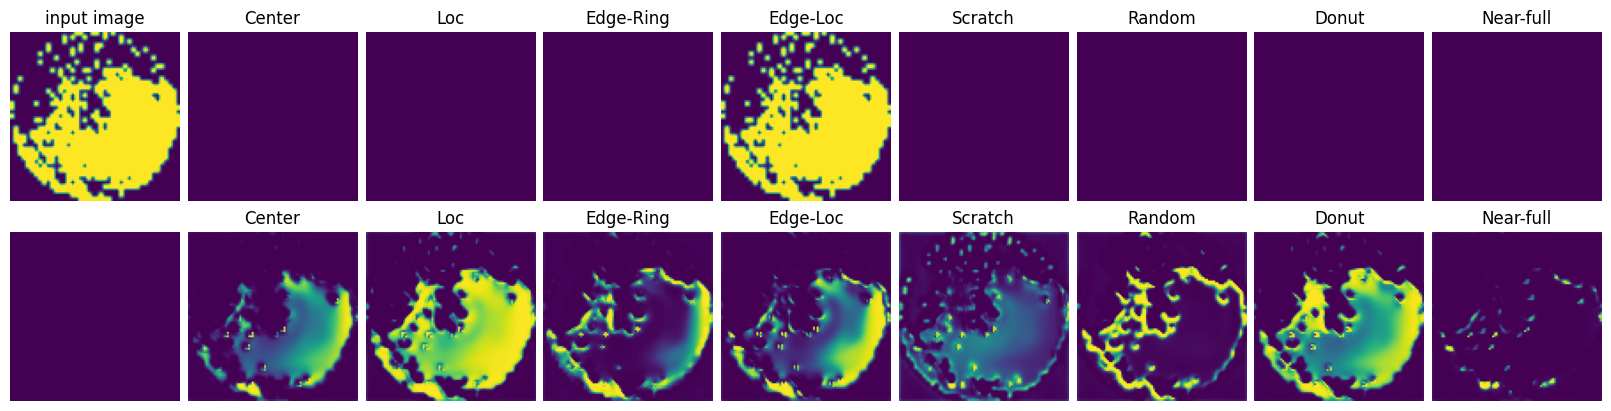

In [59]:
idx = 6
_,axs = plt.subplots(2,9, figsize=(16,4), layout='constrained')

axs[0,0].set_title('input image')
axs[0,0].imshow(input_img_batch[idx,:,:,0])
axs[1,0].imshow(np.zeros(wm811k.imsize))
for c in range(8):
    axs[0,c+1].set_title(WM_811K.defect_from_int[c])
    axs[0,c+1].imshow(output_imgs_batch[idx,:,:,c])
    axs[1,c+1].set_title(WM_811K.defect_from_int[c])
    axs[1,c+1].imshow(pred_batch[idx,:,:,c])

for ax in axs.flatten():
    ax.set_axis_off()

plt.savefig(os.path.join('..', 'plots', 'segmentation_sample.png'))